<div class='module-banner'>
<p class='module-banner-kicker'>FARMSA Portfolio Theory | Module 4</p>
<h1>DCC-GARCH Dynamic Covariance</h1>
<p class='module-banner-sub'>Time-varying covariance with dynamic volatility and correlation updates.</p>
<p class='module-banner-author'>Author: Danny</p>
</div>


## DCC-GARCH Dynamic Covariance

### Motivation

The previous methods assume that the covariance matrix is stable across a time period but this is obviously wrong. As an example think about when the COVID pandemic was first announced in March 2020 and stock correlations spiked due to panic selling.

Instead of using a static sample covariance matrix, what if we used a constantly changing covariance? This is where DCC-GARCH comes in! DCC-GARCH allows dynamic correlation between assets, essentially allowing the covariance matrix to adapt to changing market states. 

Some examples of where this model would perform well are after a volatility shocks, during market stress, during sector rotation, and when correlations are moving quickly. However it can perform poorly when the estimation window is short, there are many assets relative to data, the parameter estimation is noisy, and the future market shifts in a way the recent past did not reflect.

Generalized Autoregressive Conditional Heteroskedasticity (GARCH) is a model that is used to forecast volatility using time series data.

Dynamic Conditional Correlation (DCC) is a GARCH model that estimates time-varying correlations between financial assets.

The DCC-GARCH estimator decomposes the traditional covariance matrix into time-varying volatilities and time-varying correlations. The GARCH component captures the changing variance between assets and the DCC component updates the correlation structure using standardized returns.

### Derivation
Given a window of returns:

**Step 1:** For each asset $i$, estimate a GARCH(1,1) variance path $h_{i,t}$

**Step 2:** Construct the diagonal volatility matrix

$$D_t = \operatorname{diag}\!\left(\sqrt{h_{1,t}},\, \sqrt{h_{2,t}},\, \ldots,\, \sqrt{h_{N,t}}\right)$$

**Step 3:** Compute standardized residuals:

$$z_t = D_t^{-1}\varepsilon_t$$

**Step 4:** Estimate the long-run dependence target $\bar{Q}$ from the standardized residuals

**Step 5:** Update

$$Q_t = (1 - a - b)\bar{Q} + a\, z_{t-1}z_{t-1}^{\top} + b\, Q_{t-1}$$

**Step 6:** Normalize into a correlation matrix

$$R_t = \operatorname{diag}(Q_t)^{-1/2}\, Q_t\, \operatorname{diag}(Q_t)^{-1/2}$$

**Step 7:** Output the conditional covariance forecast

$$\hat{\Sigma}_{t} = H_t = D_t R_t D_t$$

In [1]:
# ── §2  Setup & Estimator ──────────────────────────────────
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
from scipy.optimize import minimize
warnings.filterwarnings('ignore')

# ── Load the shared universe (same 50 stocks for every module) ──
prices  = pd.read_csv('data/prices.csv',  index_col=0, parse_dates=True)
returns = pd.read_csv('data/returns.csv', index_col=0, parse_dates=True)
N, T = returns.shape[1], returns.shape[0]
print(f"Loaded {N} assets × {T} days")


def estimate_covariance(returns_df):
    """Returns an N×N covariance matrix using DCC-GARCH.
        Input:  returns_df  (pd.DataFrame, T×N daily returns) 
            Rows = time, columns = assets
        Output: H_t: N×N numpy array (symmetric, positive semi-def) 
            Estimated conditional covariance matrix
    """

    # Step 0: Convert data into a matrix
    # X is returns matrix, T is number of time periods, N is number of assets, eps is a tiny number to avoid numerical problems later
    X = returns_df.values
    # Demean daily returns
    X = X - X.mean(axis=0, keepdims=True)
    T, N = X.shape
    eps = 1e-8

    # Step 1: Estimate each asset's volatility using GARCH(1,1)
    # alpha is the weighting of how much of the previous day's shock is taken into account, beta is the weighting of how persistent volatility is
    # H_var will store the estimated variance of asset i at time t using GARCH
    alpha = 0.05
    beta = 0.90
    H_var = np.zeros((T, N))

    for i in range (N):
        r = X[:, i]

        # Sample Variance
        h = max(np.var(r), eps)
        H_var[0, i] = h

        # Calculate omega
        omega = max((1 - alpha - beta) * np.var(r), eps)

        # GARCH formula
        for t in range(1, T):
            h = omega + alpha * (r[t-1] ** 2) + beta * h
            H_var[t, i] = max(h, eps)
    
    # Step 2: Forecast next-step variances and construct D_t
    # D_t is the diagonal matrix of forecasted standard deviations
    h_next = np.zeros(N)

    for i in range(N):
        r = X[:, i]
        h_last = H_var[-1, i]
        var0 = np.var(r)
        omega = max((1 - alpha - beta) * var0, eps)
        h_next[i] = max(omega + alpha * (r[-1] ** 2) + beta * h_last, eps)
    
    sigma_t = np.sqrt(h_next)
    D_t = np.diag(sigma_t)

    # Step 3: Standardize returns
    # Z is the matrix of standardized returns
    Z = X / np.sqrt(H_var)

    # Step 4: Estimate the long-run correlation target
    # Q_bar is the long-run dependence target estimated from standardized returns 
    Q_bar = np.cov(Z.T)
    # Small adjustment to avoid singularity
    Q_bar = Q_bar + eps * np.eye(N)

    # Step 5: Run the DCC recursion
    # Choose a = 0.02 and b = 0.97 since they represent a low short-term reaction, strong persistence, and a + b < 1 so the process stays stable.
    a = 0.02
    b = 0.97
    Q = Q_bar.copy()

    for t in range(1, T):
        z_prev = Z[t-1].reshape(-1, 1)
        # (1 - a - b) * Q_bar is the pull to long-run average correlation, 
        # a * (z_prev @ z_prev.T) is the reaction to the previous day's co-movement shock
        # b * Q is the persistence from previous day's estimate
        Q = (1 - a - b) * Q_bar + a * (z_prev @ z_prev.T) + b * Q

    # Forecast the next-step correlation matrix
    z_last = Z[-1].reshape(-1, 1)
    Q = (1 - a - b) * Q_bar + a * (z_last @ z_last.T) + b * Q

    # Step 6: Convert Q into a proper correlation matrix (R_t) by normalizing
    diag_q = np.sqrt(np.maximum(np.diag(Q), eps))
    D_inv = np.diag(1.0 / diag_q)
    R = D_inv @ Q @ D_inv
    R = 0.5 * (R + R.T)

    # Step 7: Rebuild the covariance matrix
    H_t = D_t @ R @ D_t
    H_t = 0.5 * (H_t + H_t.T)

    # Step 8: Make sure output is positive semi-definite / numerically stable
    eigvals, eigvecs = np.linalg.eigh(H_t)
    eigvals = np.maximum(eigvals, eps)
    H_t = eigvecs @ np.diag(eigvals) @ eigvecs.T

    return H_t

# ── Quick sanity check (don't remove) ──
cov_test = estimate_covariance(returns.iloc[:252])
assert cov_test.shape == (N, N), f"Expected ({N},{N}), got {cov_test.shape}"
assert np.allclose(cov_test, cov_test.T), "Not symmetric"
assert np.all(np.linalg.eigvalsh(cov_test) > -1e-10), "Negative eigenvalues"
print("✓ Estimator passes sanity checks")

Loaded 50 assets × 1759 days
✓ Estimator passes sanity checks


In [2]:
# ── §3  Backtest ───────────────────────────────────────────
# This cell is ready to go — no changes needed.
# It runs a rolling monthly backtest comparing three strategies:
#   1. Equal Weight          (1/N — naive baseline)
#   2. Sample Cov MVO        (min-variance using raw sample covariance)
#   3. DCC-GARCH MVO    (min-variance using DCC-GARCH_covariance) 

def min_variance_portfolio(cov):
    """Minimum-variance portfolio (long-only, fully invested)."""
    n = cov.shape[0]
    w0 = np.ones(n) / n
    res = minimize(lambda w: w @ cov @ w, w0, method='SLSQP',
                   bounds=[(0, 1)] * n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum() - 1}],
                   options={'ftol': 1e-12, 'maxiter': 1000})
    return res.x if res.success else w0

LOOKBACK = 252   # 1 year estimation window
REBAL    = 21    # rebalance every ~1 month
MIN_HIST = 252   # need at least 1 year before first trade

dates = returns.index[MIN_HIST:]
n = returns.shape[1]

pv = {'Equal Weight': [1.0], 'Sample Cov MVO': [1.0], 'DCC-GARCH MVO': [1.0]}
cw = {k: np.ones(n) / n for k in pv}

for i, date in enumerate(dates):
    idx = returns.index.get_loc(date)
    if i % REBAL == 0:
        window = returns.iloc[idx - LOOKBACK : idx]
        cw['Equal Weight']       = np.ones(n) / n
        cw['Sample Cov MVO']     = min_variance_portfolio(window.cov().values)
        cw['DCC-GARCH MVO'] = min_variance_portfolio(estimate_covariance(window))

    day_ret = returns.iloc[idx].values
    for k in pv:
        pv[k].append(pv[k][-1] * (1 + cw[k] @ day_ret))

portfolio_df = pd.DataFrame(pv, index=[dates[0] - pd.Timedelta(days=1)] + list(dates))
print(f"✓ Backtest complete — {len(dates)} trading days")

✓ Backtest complete — 1507 trading days


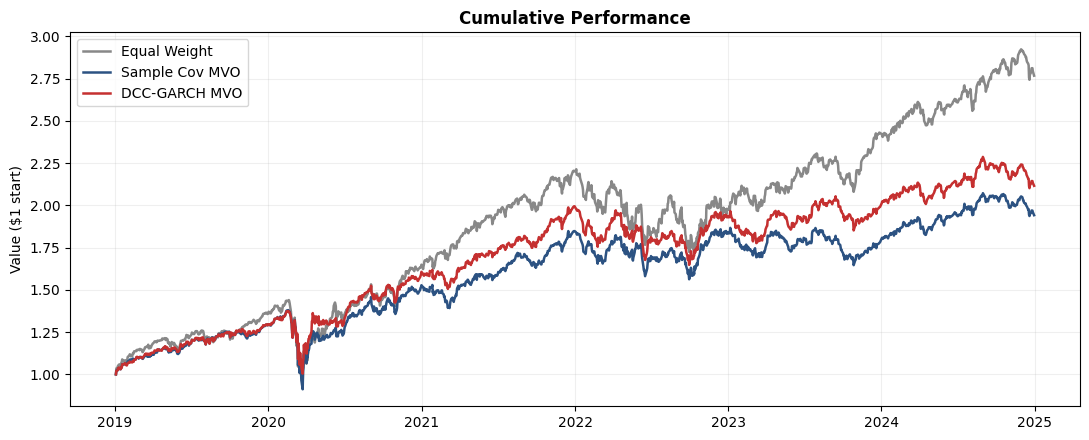

,Ret%,Vol%,Sharpe,MaxDD%
Equal Weight,19.00,19.86,0.96,-34.27
Sample Cov MVO,12.57,17.19,0.73,-33.96
DCC-GARCH MVO,13.92,16.64,0.84,-26.94


In [3]:
# ── §4  Results ────────────────────────────────────────────
C = {'Equal Weight':'#888','Sample Cov MVO':'#2c5282','DCC-GARCH MVO':'#c53030'}

fig, ax = plt.subplots(figsize=(11, 4.5))
for k in portfolio_df: ax.plot(portfolio_df.index, portfolio_df[k], label=k, color=C[k], lw=1.8)
ax.set_ylabel('Value ($1 start)'); ax.set_title('Cumulative Performance', fontweight='bold')
ax.legend(loc='upper left'); ax.grid(True, alpha=0.2); plt.tight_layout(); plt.show()

# Metrics
def metrics(v):
    r = v.pct_change().dropna()
    ar, av = r.mean()*252, r.std()*np.sqrt(252)
    return {'Ret%': ar*100, 'Vol%': av*100, 'Sharpe': ar/av if av>0 else 0,
            'MaxDD%': ((v/v.cummax())-1).min()*100}
display(pd.DataFrame({k: metrics(portfolio_df[k]) for k in portfolio_df}).T.round(2))

## Interpretation

DCC-GARCH improves on the sample covariance baseline across the board. Annual return goes from 12.57% to 13.92%, volatility drops from 17.19% to 16.64%, the Sharpe ratio rises from 0.73 to 0.84, and maximum drawdown improves from -33.96% to -26.94%. The dynamic covariance estimate is giving the optimizer a more accurate picture of current risk, and the portfolio benefits from it.

The reason is straightforward. Correlations and volatilities aren't constant. In periods of stress, correlations between assets tend to spike and volatility increases. A static sample covariance computed over a 252-day window treats last January the same as last week. DCC-GARCH weights recent observations more heavily, so the covariance matrix it produces reflects the current regime rather than an average over the whole window.

The estimator still underperforms equal weighting on raw returns. This is a recurring pattern across the modules. Minimum-variance strategies are designed to minimize risk, not maximize return, and equal weighting benefits from not relying on any covariance estimate at all. The simplified DCC implementation (fixed parameters rather than MLE-estimated) may also leave performance on the table.

Dynamic covariance estimation produces a meaningfully better minimum-variance portfolio than the static baseline. The gains are largest in drawdown control, which is where time-varying risk matters most.

## Implementation Notes

We want to find $H_t$, the conditional covariance matrix of asset returns at time $t$:

$$H_t = \operatorname{Cov}(r_t \mid \mathcal{F}_{t-1})$$

where $r_t \in \mathbb{R}^N$ is the vector of asset returns and $\mathcal{F}_{t-1}$ is the information set at time $t-1$.

#### Step 1: Decompose the covariance matrix

Separate covariance into volatilities and correlations:

$$H_t = D_t \, R_t \, D_t$$

where $D_t = \operatorname{diag}\!\left(\sqrt{h_{1,t}},\, \sqrt{h_{2,t}},\, \ldots,\, \sqrt{h_{N,t}}\right)$ is the diagonal matrix of conditional standard deviations, and $R_t$ is the time-varying correlation matrix.

#### Step 2: Model each asset's variance with GARCH(1,1)

For each asset $i$, let the return innovation be $\varepsilon_{i,t}$. Its conditional variance is modeled as

$$h_{i,t} = \omega_i + \alpha_i \varepsilon_{i,t-1}^2 + \beta_i h_{i,t-1}$$

with $\omega_i > 0,\; \alpha_i \geq 0,\; \beta_i \geq 0,\; \alpha_i + \beta_i < 1$.

#### Step 3: Standardize the residuals

Divide each innovation by its conditional volatility to isolate cross-sectional dependence:

$$z_t = D_t^{-1}\varepsilon_t$$

These standardized residuals have unit conditional variances, so the remaining dependence is captured entirely by correlation.

#### Step 4: Define the dynamic correlation process

Let $\bar{Q}$ be the unconditional covariance matrix of the standardized residuals $z_t$. The DCC(1,1) model updates the auxiliary matrix $Q_t$ as:

$$Q_t = (1 - a - b)\bar{Q} + a\, z_{t-1}z_{t-1}^{\top} + b\, Q_{t-1}$$

where $a \geq 0$ controls sensitivity to new shocks, $b \geq 0$ controls persistence, and $a + b < 1$ ensures stationarity.

#### Step 5: Normalize $Q_t$ into a correlation matrix

$$R_t = \operatorname{diag}(Q_t)^{-1/2}\, Q_t\, \operatorname{diag}(Q_t)^{-1/2}$$

This ensures $R_t$ has ones on the diagonal and valid correlations off-diagonal.

#### Step 6: Reconstruct the conditional covariance matrix

Combine the time-varying volatilities and time-varying correlations:

$$\hat{\Sigma}_t = H_t = D_t R_t D_t$$

<p style='text-align:center; color:#8fadc8; font-style:italic; font-size:0.85em;'>
Module 4 complete &mdash; see integration notebook for side-by-side comparison across all estimators.
</p>